# Práctica: Backpropagation Manual de una Compuerta AND
Este cuaderno implementa la primera iteración de entrenamiento de un perceptrón simple utilizando la notación oficial del curso.

### Parámetros y Dimensiones:
*   $a_{k,i}^0$: Activación de la capa de entrada (Capa 0) para la característica $k$ de la muestra $i$.
*   $\theta_{1k}^1$: Vector de pesos y sesgo de la neurona 1 en la capa 1.
*   $g_i$: Factor de error local de la muestra $i$.

In [1]:
import numpy as np

# 1. Definición de la función de activación (Sigmoide)
def sigma(z):
    return 1 / (1 + np.exp(-z))

print("Función de activación inicializada correctamente.")

Función de activación inicializada correctamente.


## Paso 1: Inicialización de Datos y Parámetros
Configuramos la tabla de verdad expandida (con la columna de Bias $x_0 = 1$) y definimos los valores iniciales desfavorablemente altos para observar la corrección del gradiente.

In [2]:
# Matriz de entradas de la Capa 0: a_0[muestra_i][caracteristica_k]
# k=0 (Bias), k=1 (Entrada 1), k=2 (Entrada 2)
a_0 = np.array([
    [1, 0, 0],  # i = 1 (Muestra 1)
    [1, 0, 1],  # i = 2 (Muestra 2)
    [1, 1, 0],  # i = 3 (Muestra 3)
    [1, 1, 1]   # i = 4 (Muestra 4)
])

# Vector de objetivos (Target para la compuerta AND)
t = np.array([0, 0, 0, 1])

# Parámetros iniciales de la Neurona 1 en la Capa 1
theta_10 = 0.2  # Sesgo (b_1)
theta_11 = 0.4  # Peso de la Entrada 1 (w_11)
theta_12 = 0.3  # Peso de la Entrada 2 (w_21)

# Agrupamos en un vector para simular la estructura de la pizarra
theta_1 = np.array([theta_10, theta_11, theta_12])
alpha = 0.1  # Factor de aprendizaje

print("Pesos iniciales [θ10, θ11, θ12]:", theta_1)

Pesos iniciales [θ10, θ11, θ12]: [0.2 0.4 0.3]


## Pasos 2 y 3: Forward Pass y Factores de Error Local ($g_i$)
Calculamos la entrada neta $z_{1,i}^1 = \sum_k \theta_{1k}^1 a_{k,i}^0$, la activación $a_{1,i}^1 = \sigma(z_{1,i}^1)$ y el indicador de error $g_i = -(t_i - a_{1,i}^1) \cdot a_{1,i}^1 \cdot (1 - a_{1,i}^1)$ muestra por muestra.

In [3]:
# Listas para almacenar los resultados de cada muestra
z_1 = []
a_1 = []
g = []

print("--- EVALUACIÓN POR MUESTRA ---")
for i in range(4):
    # Sumatoria sobre k (k=0, k=1, k=2) para la muestra i
    z_i_neto = theta_1[0]*a_0[i][0] + theta_1[1]*a_0[i][1] + theta_1[2]*a_0[i][2]
    a_i_activacion = sigma(z_i_neto)

    # Ecuación del factor de error de la pizarra
    g_i_error = -(t[i] - a_i_activacion) * a_i_activacion * (1 - a_i_activacion)

    # Guardamos los valores
    z_1.append(z_i_neto)
    a_1.append(a_i_activacion)
    g.append(g_i_error)

    print(f"Muestra {i+1}: z = {z_i_neto:.1f} | a = {a_i_activacion:.4f} | g = {g_i_error:.4f}")

--- EVALUACIÓN POR MUESTRA ---
Muestra 1: z = 0.2 | a = 0.5498 | g = 0.1361
Muestra 2: z = 0.5 | a = 0.6225 | g = 0.1463
Muestra 3: z = 0.6 | a = 0.6457 | g = 0.1477
Muestra 4: z = 0.9 | a = 0.7109 | g = -0.0594


## Paso 4: Construcción del Vector Gradiente $\nabla E$
Evaluamos las derivadas parciales acumulando el impacto de las 4 muestras mediante la fórmula:
$$\frac{\partial E}{\partial \theta_{1k}^1} = \sum_{i} g_i \cdot a_{k,i}^0$$

In [4]:
# Inicializamos las derivadas parciales en cero
dE_dtheta10 = 0
dE_dtheta11 = 0
dE_dtheta12 = 0

# Aplicamos la sumatoria explícita sobre i
for i in range(4):
    dE_dtheta10 += g[i] * a_0[i][0]  # Multiplica por la columna del Bias
    dE_dtheta11 += g[i] * a_0[i][1]  # Multiplica por la columna Entrada 1
    dE_dtheta12 += g[i] * a_0[i][2]  # Multiplica por la columna Entrada 2

# Construimos el vector gradiente total
grad_E = np.array([dE_dtheta10, dE_dtheta11, dE_dtheta12])

print("Vector Gradiente ∇E calculado:")
print(f"  ∂E/∂θ10 (Bias)      = {dE_dtheta10:.4f}")
print(f"  ∂E/∂θ11 (Entrada 1) = {dE_dtheta11:.4f}")
print(f"  ∂E/∂θ12 (Entrada 2) = {dE_dtheta12:.4f}")

Vector Gradiente ∇E calculado:
  ∂E/∂θ10 (Bias)      = 0.3707
  ∂E/∂θ11 (Entrada 1) = 0.0883
  ∂E/∂θ12 (Entrada 2) = 0.0869


## Paso 5: Actualización de Parámetros (Ley de Cauchy)
Aplicamos el ajuste mediante el descenso del gradiente: $\vec{\theta}_{nuevo} = \vec{\theta}_{viejo} - \alpha \nabla E$.

In [5]:
# Ley de Cauchy aplicada al vector completo
theta_1_nuevo = theta_1 - alpha * grad_E

print("--- COMPARATIVA DE PARÁMETROS TRAS ITERACIÓN 1 ---")
print(f"Sesgo θ10:    {theta_1[0]:.4f}  -->  {theta_1_nuevo[0]:.4f}")
print(f"Peso x1 θ11:  {theta_1[1]:.4f}  -->  {theta_1_nuevo[1]:.4f}")
print(f"Peso x2 θ12:  {theta_1[2]:.4f}  -->  {theta_1_nuevo[2]:.4f}")

--- COMPARATIVA DE PARÁMETROS TRAS ITERACIÓN 1 ---
Sesgo θ10:    0.2000  -->  0.1629
Peso x1 θ11:  0.4000  -->  0.3912
Peso x2 θ12:  0.3000  -->  0.2913


## Paso 6: Proceso de Entrenamiento Completo (Ciclo de Épocas)
Para encontrar los valores óptimos finales de los pesos y el sesgo, reinicializaremos los parámetros y ejecutaremos el algoritmo iterativamente a lo largo de múltiples **épocas**.

En cada época, calcularemos adicionalmente el **Error Cuadrático Medio (MSE)** para monitorear el progreso del aprendizaje:
$$MSE = \frac{1}{4}\sum_{i=1}^{4} \frac{1}{2}(a_{1,i}^1 - t_i)^2$$

In [6]:
import matplotlib.pyplot as plt

# Reinicializamos los parámetros para empezar desde el mismo punto de partida
theta_1 = np.array([0.2, 0.4, 0.3]) # [Sesgo θ10, Peso x1 θ11, Peso x2 θ12]
alpha = 0.1                         # Factor de aprendizaje
epochs = 2000                       # Número de épocas de entrenamiento

# Lista para guardar el historial del error y graficarlo después
historial_error = []

print("Iniciando el entrenamiento...\n")

for epoch in range(epochs):
    # Inicializadores para acumular el gradiente y el error de esta época
    dE_dtheta10 = 0
    dE_dtheta11 = 0
    dE_dtheta12 = 0
    error_cuadratico_total = 0

    # Lista temporal de factores de error para esta época
    g_epoca = []

    # 1. FORWARD PASS Muestra por Muestra
    for i in range(4):
        z_i = theta_1[0]*a_0[i][0] + theta_1[1]*a_0[i][1] + theta_1[2]*a_0[i][2]
        a_i = sigma(z_i)

        # Guardamos el indicador de error g_i
        g_i = -(t[i] - a_i) * a_i * (1 - a_i)
        g_epoca.append(g_i)

        # Acumulamos el error cuadrático de la muestra: 0.5 * (a_i - t_i)^2
        error_cuadratico_total += 0.5 * (a_i - t[i])**2

    # Calculamos el MSE de la época actual (promedio de los errores)
    mse = error_cuadratico_total / 4
    historial_error.append(mse)

    # 2. BACKWARD PASS (Acumulación del gradiente mediante sumatoria)
    for i in range(4):
        dE_dtheta10 += g_epoca[i] * a_0[i][0]
        dE_dtheta11 += g_epoca[i] * a_0[i][1]
        dE_dtheta12 += g_epoca[i] * a_0[i][2]

    grad_E = np.array([dE_dtheta10, dE_dtheta11, dE_dtheta12])

    # 3. ACTUALIZACIÓN (Ley de Cauchy)
    theta_1 = theta_1 - alpha * grad_E

    # Imprimimos el progreso cada 200 épocas
    if (epoch + 1) % 200 == 0 or epoch == 0:
        print(f"Época {epoch+1:4d} | MSE: {mse:.6f} | Pesos actuales: [{theta_1[0]:.4f}, {theta_1[1]:.4f}, {theta_1[2]:.4f}]")

print("\n¡Entrenamiento finalizado con éxito!")

Iniciando el entrenamiento...

Época    1 | MSE: 0.148774 | Pesos actuales: [0.1629, 0.3912, 0.2913]
Época  200 | MSE: 0.051213 | Pesos actuales: [-1.8023, 1.0492, 1.0255]
Época  400 | MSE: 0.033947 | Pesos actuales: [-2.6142, 1.6317, 1.6256]
Época  600 | MSE: 0.025094 | Pesos actuales: [-3.2119, 2.0449, 2.0431]
Época  800 | MSE: 0.019652 | Pesos actuales: [-3.6847, 2.3680, 2.3674]
Época 1000 | MSE: 0.015993 | Pesos actuales: [-4.0738, 2.6325, 2.6322]
Época 1200 | MSE: 0.013388 | Pesos actuales: [-4.4029, 2.8553, 2.8552]
Época 1400 | MSE: 0.011453 | Pesos actuales: [-4.6870, 3.0472, 3.0472]
Época 1600 | MSE: 0.009969 | Pesos actuales: [-4.9360, 3.2152, 3.2152]
Época 1800 | MSE: 0.008800 | Pesos actuales: [-5.1571, 3.3643, 3.3642]
Época 2000 | MSE: 0.007859 | Pesos actuales: [-5.3557, 3.4979, 3.4979]

¡Entrenamiento finalizado con éxito!


## Paso 7: Visualización de la Curva de Aprendizaje
Graficamos el comportamiento del error ($MSE$) a lo largo del tiempo para verificar que el Descenso del Gradiente minimizó la función de costo correctamente.

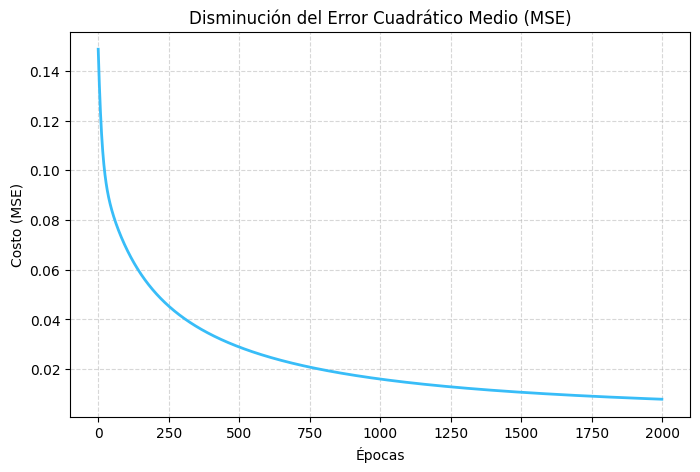

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(historial_error, color='#38bdf8', linewidth=2)
plt.title('Disminución del Error Cuadrático Medio (MSE)')
plt.xlabel('Épocas')
plt.ylabel('Costo (MSE)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Paso 8: Evaluación y Verificación del Modelo Entrenado
Utilizamos los valores finales de pesos y sesgo calculados por el algoritmo para realizar un último Forward Pass. De esta manera, validamos si la neurona artificial ya es capaz de resolver la lógica de la compuerta **AND**.

In [8]:
print("=== RESULTADOS FINALES DEL MODELO ===")
print(f"Sesgo final (θ10)      = {theta_1[0]:.4f}")
print(f"Peso final x1 (θ11)   = {theta_1[1]:.4f}")
print(f"Peso final x2 (θ12)   = {theta_1[2]:.4f}\n")

print("--- TABLA DE PREDICCIONES ---")
print(f"{'Muestra':<10} | {'X1':<4} | {'X2':<4} | {'Target':<8} | {'Predicción (a_1^1)':<20} | ¿Clasificó bien?")
print("-" * 75)

for i in range(4):
    # Calculamos la salida con los parámetros finales optimizados
    z_final = theta_1[0]*a_0[i][0] + theta_1[1]*a_0[i][1] + theta_1[2]*a_0[i][2]
    prediccion = sigma(z_final)

    # Clasificación binaria con umbral de 0.5
    resultado_binario = 1 if prediccion >= 0.5 else 0
    exito = "SÍ" if resultado_binario == t[i] else "NO"

    print(f"Muestra {i+1:<3} | {int(a_0[i][1]):<4} | {int(a_0[i][2]):<4} | {t[i]:<8} | {prediccion:<20.6f} | {exito}")

=== RESULTADOS FINALES DEL MODELO ===
Sesgo final (θ10)      = -5.3557
Peso final x1 (θ11)   = 3.4979
Peso final x2 (θ12)   = 3.4979

--- TABLA DE PREDICCIONES ---
Muestra    | X1   | X2   | Target   | Predicción (a_1^1)   | ¿Clasificó bien?
---------------------------------------------------------------------------
Muestra 1   | 0    | 0    | 0        | 0.004699             | SÍ
Muestra 2   | 0    | 1    | 0        | 0.134959             | SÍ
Muestra 3   | 1    | 0    | 0        | 0.134961             | SÍ
Muestra 4   | 1    | 1    | 1        | 0.837552             | SÍ


## Paso 9: Visualización de la Frontera de Decisión Lineal
Para comprender geométricamente cómo clasifica nuestro modelo, calculamos la recta límite en el espacio de entradas (donde la neurona no discrimina entre ambas clases, es decir, cuando $z_1^1 = 0$).

Despejando la segunda entrada ($a_2^0$) en función de la primera entrada ($a_1^0$), obtenemos la ecuación de la recta:
$$a_2^0 = -\left(\frac{w_{11}^1}{w_{21}^1}\right)a_1^0 - \frac{b_1^1}{w_{21}^1}$$

Graficaremos esta línea límite superpuesta sobre las activaciones de las 4 muestras para verificar la separación física del espacio.

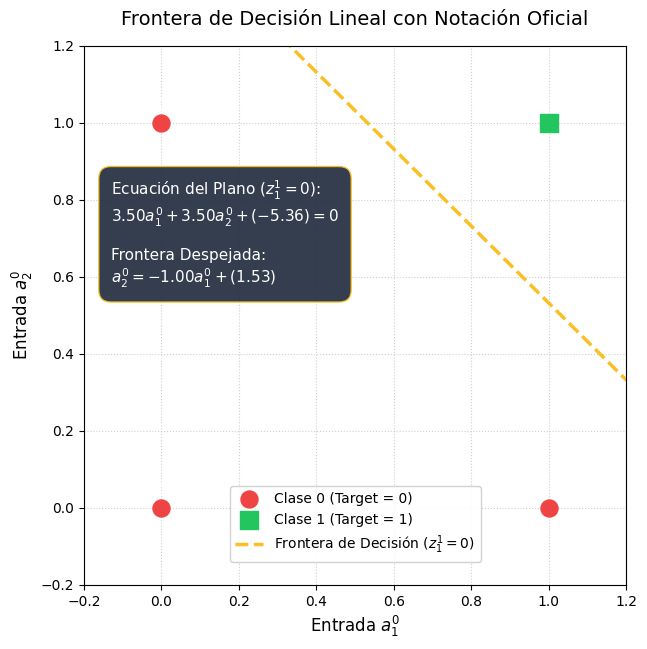

In [20]:
# 1. Definimos el rango para el eje horizontal (Entrada a1_0)
a1_0_linea = np.linspace(-0.2, 1.2, 100)

# 2. Calculamos el eje vertical (Entrada a2_0) usando la notación de la pizarra
a2_0_linea = -(theta_1[1] * a1_0_linea + theta_1[0]) / theta_1[2]

# 3. Construcción del gráfico
plt.figure(figsize=(7, 7))

# Graficamos los puntos de la Clase 0 (Muestras 1, 2 y 3, donde AND = 0)
plt.scatter(a_0[:3, 1], a_0[:3, 2], color='#ef4444', s=150, marker='o', label='Clase 0 (Target = 0)', zorder=5)

# Graficamos el punto de la Clase 1 (Muestra 4, donde AND = 1)
plt.scatter(a_0[3, 1], a_0[3, 2], color='#22c55e', s=150, marker='s', label='Clase 1 (Target = 1)', zorder=5)

# Graficamos la frontera de decisión (z1_1 = 0)
plt.plot(a1_0_linea, a2_0_linea, color='#fbbf24', linestyle='--', linewidth=2.5, label='Frontera de Decisión ($z_1^1=0$)')

# =========================================================================
# CUADRO DE TEXTO CON LA ECUACIÓN DINÁMICA
# =========================================================================
p_m = -(theta_1[1] / theta_1[2]) # Pendiente
p_c = -(theta_1[0] / theta_1[2]) # Intersección

texto_ecuacion = (
    f"Ecuación del Plano ($z_1^1 = 0$):\n"
    f"${theta_1[1]:.2f}a_1^0 + {theta_1[2]:.2f}a_2^0 + ({theta_1[0]:.2f}) = 0$\n\n"
    f"Frontera Despejada:\n"
    f"$a_2^0 = {p_m:.2f}a_1^0 + ({p_c:.2f})$"
)

plt.text(0.05, 0.65, texto_ecuacion,
         transform=plt.gca().transAxes,
         fontsize=11,
         color='white',
         verticalalignment='center',
         bbox=dict(facecolor='#1e293b', alpha=0.9, edgecolor='#fbbf24', boxstyle='round,pad=0.8'))
# =========================================================================

# Ajustes de ejes y etiquetas oficiales
plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xlabel('Entrada $a_1^0$', fontsize=12)
plt.ylabel('Entrada $a_2^0$', fontsize=12)
plt.title('Frontera de Decisión Lineal con Notación Oficial', fontsize=14, pad=15)
plt.grid(True, linestyle=':', alpha=0.6)

# =========================================================================
# CORREGIDO: LEYENDA MOVIDA AL ESPACIO VACÍO EN FORMATO HORIZONTAL
# =========================================================================
# loc='lower center' la centra abajo, y bbox_to_anchor la sube sutilmente a la zona libre
# ncol=3 distribuye las 3 etiquetas en una sola fila horizontal
plt.legend(loc='lower center', bbox_to_anchor=(0.5, 0.03), framealpha=0.9)
# =========================================================================

# Anotaciones de las muestras
for i in range(4):
    plt.annotate(f"M{i+1} ({int(a_0[i][1])},{int(a_0[i][2])})",
                 (a_0[i][1], a_0[i][2]),
                 textcoords="offset points",
                 xytext=(0,10),
                 ha='center',
                 fontweight='bold',
                 color='white')

plt.show()